# Pyomo.DoE: Optimization

In the [previous notebook](doe_optimize.ipynb), we formulated model-based design of experiments as an optimal control problem using one objective function: pseudo A-optimality, based on $\log_{10}(\mathrm{trace}(\mathrm{FIM}))$.

In this workbook, we extend that idea to additional optimality criteria. We will use Pyomo.DoE to formulate, initialize, and solve experiment design problems using D-, A-, E-, and ME-optimality objectives. This lets us compare how the choice of design criterion changes the optimized input profile, $u(t)$, and the information content of the resulting experiment. Re-stating the optimal control formulation, we maximize a scalar-valued function $\psi(\cdot)$ of the Fisher information matrix, $\mathbf{M}$, subject to the TC Lab dynamic model, heater-input bounds, and initial conditions. 

Maximize a scalar-valued function $\psi(\cdot)$ of the Fisher information matrix $\mathbf{M}$:

$$
\begin{align*}
\max_{u} \quad & \psi(\mathbf{M}(u) + \mathbf{M}_0) \\
\mathrm{s.t.} \quad & C_p^H \frac{dT_H}{dt} = U_a (T_{amb} - T_H) + U_b (T_S - T_H) + \alpha P u(t)\\
& C_p^S \frac{dT_S}{dt} = U_b (T_H - T_S)  \\
& 0\% \leq u(t) \leq 100 \% \\
& T_H(t_0) = T_{amb} \\
& T_S(t_0) = T_{amb}
\end{align*}
$$

`Pyomo.DoE` automatically formulates, initializes, and solves this optimization problem for different choices of $\psi(\cdot)$, allowing us to compare D-, A-, E-, and ME-optimality criteria.

In [22]:
import sys

# If running on Google Colab, install Pyomo and Ipopt via IDAES
on_colab = "google.colab" in sys.modules
if on_colab:
    !wget "https://raw.githubusercontent.com/dowlinglab/pyomo-doe/main/notebooks/tclab_pyomo.py"

# import TCLab model, simulation, and data analysis functions
from tclab_pyomo import (
    TC_Lab_data,
    TC_Lab_experiment,
    extract_results,
    extract_plot_results,
    results_summary,
)

# set default number of states in the TCLab model
number_tclab_states = 2

## Load experimental data (sine test)

We will load the sine test data to serve as an initial point. Recall our create model function will use supplied data to initialize the Pyomo model. Carefully initialization is often required for optimization of large-scale dynamic systems.

In [23]:
import pandas as pd

if on_colab:
    file = "https://raw.githubusercontent.com/dowlinglab/pyomo-doe/main/data/tclab_sine_test_5min_period.csv"
else:
    file = '../data/tclab_sine_test_5min_period.csv'
df = pd.read_csv(file)
df.head()

,Time,T1,T2,Q1,Q2
0,0.00,22.2,22.2,50,0
1,1.01,22.2,22.2,51,0
2,2.01,22.2,22.2,52,0
3,3.00,22.2,22.2,53,0
4,4.01,22.2,22.2,54,0


We will create the data object for the design of experiment problems that follow, but first ee will define a prior FIM from $L_2$ regularization 

In [24]:
import numpy as np

cov = np.array([
    [1.857017e-10, -2.576198e-10, 1.402148e-09, -2.242347e-12],
    [-2.576198e-10, 1.624383e-07, 9.10987e-08, -6.32555e-05],
    [1.402148e-09, 9.10987e-08, 1.031454e-07, -3.890789e-05],
    [-2.242347e-12, -6.325555e-05, -3.890789e-05, 2.499914e-02],
])

FIM = np.linalg.inv(cov)

# Make sure resultant FIM is symmetric within numerical tolerance

FIM = 0.5*(FIM + FIM.T)


results_summary(FIM)

======Results Summary======
Five design criteria log10() value:
Pseudo A-optimality: 9.910292691839132
A-optimality: -1.6020703142836739
D-optimality: 27.78192769305941
E-optimality: 1.602071098783679
Modified E-optimality: 8.254407440634093

FIM:
 [[ 7.17766368e+09  1.00807351e+08 -2.18903119e+08 -8.56197638e+04]
 [ 1.00807351e+08  8.99218639e+08  1.51868463e+08  2.51166355e+06]
 [-2.18903119e+08  1.51868463e+08  5.68956091e+07  4.72824543e+05]
 [-8.56197638e+04  2.51166355e+06  4.72824543e+05  7.13117338e+03]]

eigenvalues:
 [7.18585649e+09 9.25169344e+08 2.27591910e+07 4.00010230e+01]

Eigenvector matrix:
          eigvec_1  eigvec_2  eigvec_3  eigvec_4
Ua         0.9994    0.0098    0.0326   -0.0000
Ub         0.0153   -0.9846   -0.1743   -0.0025
inv_CpH   -0.0304   -0.1747    0.9842   -0.0016
inv_CpS   -0.0000   -0.0028    0.0011    1.0000


In [25]:
# Here, we will induce a step size of 15 seconds, as to not give too many 
# degrees of freedom for experimental design.
skip =15

# Create the data object considering the new control points every 6 seconds
tc_data = TC_Lab_data(
    name="Sine Wave Test for Heater 1",
    time=df['Time'].values[::skip],
    T1=df['T1'].values[::skip],
    u1=df['Q1'].values[::skip],
    P1=200,
    TS1_data=None,
    T2=df['T2'].values[::skip],
    u2=df['Q2'].values[::skip],
    P2=200,
    TS2_data=None,
    Tamb=df['T1'].values[0],
)

#Re-Calculate FIM at initial point (Values from $L_2$ regularization)
# Load Pyomo.DoE class
from pyomo.contrib.doe import DesignOfExperiments

from pyomo.environ import SolverFactory

# Copied from previous notebook
theta_values = {
    'Ua': 0.041705,
    'Ub': 0.012009,
    'inv_CpH': 0.167457,
    'inv_CpS': 4.545432,
}

# Re-create experiment object for design of experiments
doe_experiment = TC_Lab_experiment(data=tc_data, theta_initial=theta_values, number_of_states=number_tclab_states)

solver = SolverFactory("ipopt")
solver.options["max_iter"] = 3000
solver.options["tol"] = 1e-5
solver.options["linear_solver"] = "ma57"
solver.options["nlp_scaling_method"] = "gradient-based"
solver.options["acceptable_tol"] = 1e-3

doe_experiment = TC_Lab_experiment(data=tc_data, theta_initial=theta_values, number_of_states=number_tclab_states)
# Re-create the design of experiments object using our experiment instance from above
TC_Lab_DoE = DesignOfExperiments(experiment=doe_experiment, 
                                 step=1e-2,
                                 scale_constant_value=1,
                                 scale_nominal_param_value=False, 
                                 prior_FIM=FIM,
                                 tee=True,
                                 solver = solver,)
# Get the FIM and the jacobian at the initial solve
try:
    init_fim = TC_Lab_DoE.compute_FIM()
    init_jac = TC_Lab_DoE.seq_jac 
except:
    init_fim = None
    init_jac = None

Ipopt 3.14.19: max_iter=3000
tol=1e-05
linear_solver=ma57
nlp_scaling_method=gradient-based
acceptable_tol=0.001


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************

This is Ipopt version 3.14.19, running with linear solver ma57.

Number of nonzeros in equality constraint Jacobian...:      720
Number of nonzeros in inequality constraint Jacobian.:        0
Number of nonzeros in Lagrangian Hessian.............:        0

Total number of variables............................:      242
                     variables with only lower bounds:        0
                variables with lower and upper bounds:      120
                     variables with only upper bo

## Optimize next experiment (A-optimality)

We are now ready to solve the next experiment design problem. Here, we create a new `DesignOfExperiments` object and pass in the `prior_FIM`, which represents the information already collected from the previous experiment. By optimizing with this prior information included, Pyomo.DoE identifies the next best experiment to run according to the selected design criterion. In this section, we use A-optimality by setting `objective_option="trace"`. This objective is the true A-optimality condition that minimizes the trace of the inverse of the Fisher information matrix

In [26]:
# Create experiment object for design of experiments
doe_experiment = TC_Lab_experiment(data=tc_data, theta_initial=theta_values, number_of_states=number_tclab_states)


# Create the design of experiments object using our experiment instance from above
TC_Lab_DoE_A = DesignOfExperiments(experiment=doe_experiment, 
                                 step=1e-2,
                                 scale_constant_value=1,
                                 scale_nominal_param_value=False,
                                 objective_option="trace",  # Now we specify a type of objective, A-opt = "trace"
                                 prior_FIM=FIM,  # We use the prior information from the same existing experiment as in the D-optimal case!
                                 tee=True,
                                 solver = solver,
                                jac_initial=init_jac,
                                fim_initial=init_fim,)

TC_Lab_DoE_A.run_doe()

Ipopt 3.14.19: max_iter=3000
tol=1e-05
linear_solver=ma57
nlp_scaling_method=gradient-based
acceptable_tol=0.001


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************

This is Ipopt version 3.14.19, running with linear solver ma57.

Number of nonzeros in equality constraint Jacobian...:      720
Number of nonzeros in inequality constraint Jacobian.:        0
Number of nonzeros in Lagrangian Hessian.............:        0

Total number of variables............................:      242
                     variables with only lower bounds:        0
                variables with lower and upper bounds:      120
                     variables with only upper bo

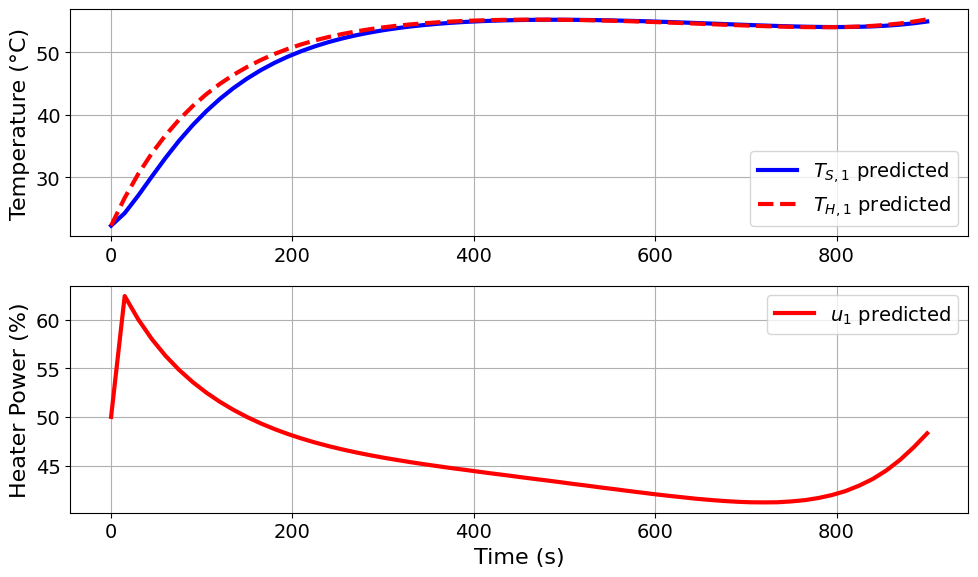

Model parameters:
Ua = 0.0421 Watts/°C
Ub = 0.012 Watts/°C
CpH = 5.9717 Joules/°C
CpS = 0.22 Joules/°C
 


In [27]:
aopt_pyomo_doe_results = extract_plot_results(None, TC_Lab_DoE_A.model.fd_scenario_blocks[0])

Interestingly, the A-optimal design produces an optimized experiment that differs from the initial sine-wave experiment. The optimized input has a structured heating profile, with heater power initially increasing and then gradually decreasing before rising again near the end of the experiment.

The predicted temperature trajectory remains in a relatively high temperature range for much of the experiment. This suggests that, for this example, the A-optimal criterion favors an experiment that maintains initial heating followed by a gradual cooling behavior.


Now, let us check whether the updated FIM after the A-optimal experiment is full rank.

In [28]:
FIM_new = TC_Lab_DoE_A.results["FIM"]

FIM_array = FIM_new.to_numpy(dtype=float) if isinstance(FIM, pd.DataFrame) else np.asarray(FIM, dtype=float)

rank = np.linalg.matrix_rank(FIM_array)
num_params = FIM_array.shape[0]


print(f"FIM rank:{rank} out of {num_params} parameters")

FIM rank:4 out of 4 parameters


The updated FIM has rank 4 out of 4, so it is full rank. This means that the prior information and the new A-optimal experiment together provide independent information about all four parameter directions.

Next, we examine the eigendecomposition of the updated FIM to understand how well the different parameter directions are informed.

In [29]:
results_summary(TC_Lab_DoE_A.results['FIM'])

======Results Summary======
Five design criteria log10() value:
Pseudo A-optimality: 11.075025561486314
A-optimality: -5.595150642107628
D-optimality: 33.12626085549312
E-optimality: 5.600977974805883
Modified E-optimality: 5.4705156867473095

FIM:
 [[np.float64(117891629642.70352), np.float64(581316096.9054723), np.float64(-40516944.961708955), np.float64(1409086.0757141053)], [np.float64(581316096.9054723), np.float64(907371904.7147728), np.float64(154221799.89593962), np.float64(2535037.9075805666)], [np.float64(-40516944.961708955), np.float64(154221799.89593962), np.float64(57810462.375325575), np.float64(479810.25539204176)], [np.float64(1409086.0757141053), np.float64(2535037.9075805666), np.float64(479810.25539204176), np.float64(406166.442019446)]]

eigenvalues:
 [1.17894532e+11 9.31774982e+08 3.05125268e+07 3.99004666e+05]

Eigenvector matrix:
          eigvec_1  eigvec_2  eigvec_3  eigvec_4
Ua        -1.0000   -0.0048   -0.0012   -0.0000
Ub        -0.0050    0.9847    0.1740

The eigendecomposition shows that the least-informed parameter direction is dominated by $\mathrm{inv}\_C_p^S$, as indicated by the fourth eigenvector. 

These results suggest that the prior information and the new A-optimal experiment together provide enough independent information to estimate all four model parameters. However, the smallest eigenvalue is still associated primarily with $\mathrm{inv}\_C_p^S$, so additional experiments that increase information in the direction of the smallest value could further improve conditioning. This leads us to the E and ME-optimalty criteria.

The A-optimal experiment makes the updated FIM full rank, but the eigendecomposition shows that the information is still unevenly distributed across parameter directions. This motivates eigenvalue-based criteria that focus directly on the weakest-informed direction.

E-optimality and modified E-optimality both depend directly on the eigenvalues of $\mathbf{M}(u) + \mathbf{M}_0$:


E-optimality and modified E-optimality are different because they depend directly on the eigenvalues of $\mathbf{M}(u) + \mathbf{M}_0$:

$$
\text{E-optimality:} \qquad
\max_u \ \lambda_{\min}(\mathbf{M}(u) + \mathbf{M}_0),
$$

$$
\text{Modified E-optimality:} \qquad
\min_u \
\frac{\lambda_{\max}(\mathbf{M}(u) + \mathbf{M}_0)}
{\lambda_{\min}(\mathbf{M}(u) + \mathbf{M}_0)}.
$$
E-optimality maximizes the smallest eigenvalue, so it directly targets the weakest-informed parameter direction. Modified E-optimality instead reduces the spread between the largest and smallest eigenvalues, which is related to improving the conditioning of the FIM. We will put a pin in modified E-optimality for now and focus first on E-optimality.


## E-optimality using GreyBox Formulation

Eigenvalue-based objectives are not as convenient to express using standard algebraic constraints. Pyomo.DoE therefore uses a GreyBox formulation for objectives such as E-optimality and modified E-optimality.

In this formulation, the Pyomo model computes the total Fisher information matrix,

$$
\mathbf{M}(u) + \mathbf{M}_0,
$$

and the GreyBox block evaluates the scalar design criterion externally as

$$
\psi = \psi\left(\mathbf{M}(u) + \mathbf{M}_0\right).
$$

For E-optimality, the GreyBox block evaluates

$$
\psi\left(\mathbf{M}(u) + \mathbf{M}_0\right)
=
\lambda_{\min}\left(\mathbf{M}(u) + \mathbf{M}_0\right).
$$

Thus:

- the Pyomo model computes $\mathbf{Q}(u)$ and $\mathbf{M}(u) + \mathbf{M}_0$,
- the GreyBox block takes $\mathbf{M}(u) + \mathbf{M}_0$ as input,
- the GreyBox block returns the smallest eigenvalue, $\lambda_{\min}\left(\mathbf{M}(u) + \mathbf{M}_0\right)$, as the scalar objective value.

The GreyBox callback also provides derivative information, such as

$$
\frac{\partial \psi}{\partial \mathbf{M}},
$$

and optionally second-derivative information. This allows a gradient-based optimizer such as IPOPT to solve the resulting problem efficiently.


We now formulate and solve the next experiment design problem using the GreyBox objective implementation with `objective_option="minimum_eigenvalue"`.

In [30]:
# Create the design of experiments object for E-optimality

TC_Lab_DoE_E = DesignOfExperiments(
    experiment=doe_experiment,
    step=1e-2,
    scale_constant_value=1,
    scale_nominal_param_value=False,
    objective_option="minimum_eigenvalue",  # E-optimality
    prior_FIM=FIM,
    tee=True,
    solver = solver,
    jac_initial=init_jac,
    fim_initial=init_fim,
)

# Use the GreyBox objective implementation
TC_Lab_DoE_E.use_grey_box = True

# Solve the E-optimal design problem
TC_Lab_DoE_E.run_doe()


Ipopt 3.14.19: max_iter=3000
tol=1e-05
linear_solver=ma57
nlp_scaling_method=gradient-based
acceptable_tol=0.001


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************

This is Ipopt version 3.14.19, running with linear solver ma57.

Number of nonzeros in equality constraint Jacobian...:      720
Number of nonzeros in inequality constraint Jacobian.:        0
Number of nonzeros in Lagrangian Hessian.............:        0

Total number of variables............................:      242
                     variables with only lower bounds:        0
                variables with lower and upper bounds:      120
                     variables with only upper bo

In [31]:
print("=== E-optimal design summary ===")


results_summary(TC_Lab_DoE_E.results["FIM"])


=== E-optimal design summary ===
======Results Summary======
Five design criteria log10() value:
Pseudo A-optimality: 11.119019609917302
A-optimality: -7.1763134437450065
D-optimality: 35.053975438618416
E-optimality: 7.484445384297484
Modified E-optimality: 3.6312833535869697

FIM:
 [[np.float64(130532767531.74484), np.float64(597206757.266401), np.float64(-39265091.545517586), np.float64(1448652.1909491422)], [np.float64(597206757.266401), np.float64(907355101.2352778), np.float64(154186484.4875165), np.float64(2377729.9028129983)], [np.float64(-39265091.545517586), np.float64(154186484.4875165), np.float64(57782750.143554136), np.float64(418295.0760095752)], [np.float64(1448652.1909491422), np.float64(2377729.9028129983), np.float64(418295.0760095752), np.float64(30516671.05308694)]]

eigenvalues:
 [1.30535530e+11 9.31871291e+08 3.05102232e+07 3.05102232e+07]

Eigenvector matrix:
          eigvec_1  eigvec_2  eigvec_3  eigvec_4
Ua         1.0000    0.0045   -0.0011    0.0000
Ub     

The E-optimal design increases the smallest eigenvalue of the updated FIM from approximately $3.99 \times 10^5$ for the A-optimal design to approximately $3.05 \times 10^7$. This is about a 76-fold increase in the least-informed parameter direction.

The eigendecomposition still shows that this weakest direction is dominated by $\mathrm{inv}\_C_p^S$. Thus, E-optimality does not change which parameter direction is least informed; instead, it directly increases the information available in that direction.

We next visualize the optimized experiment.

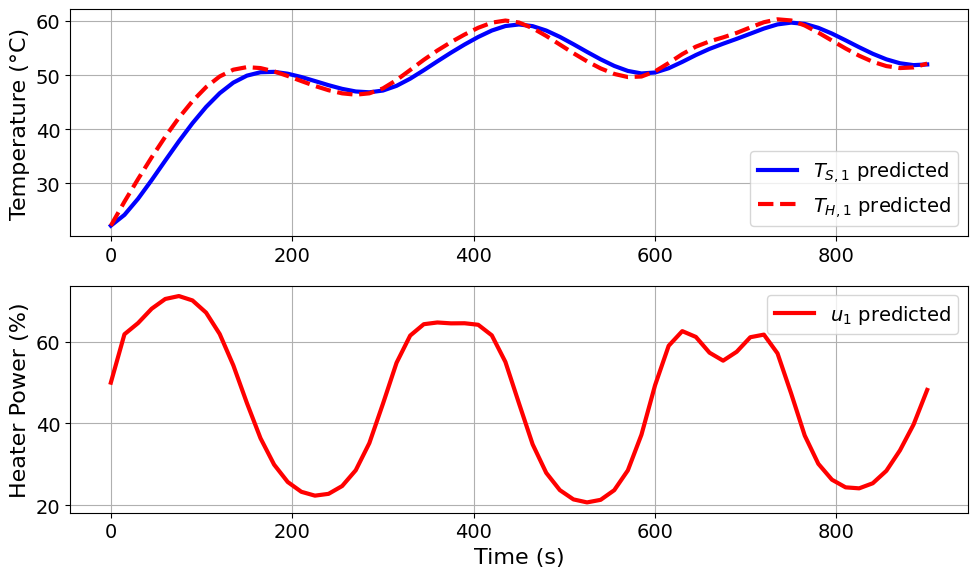

Model parameters:
Ua = 0.0421 Watts/°C
Ub = 0.012 Watts/°C
CpH = 5.9717 Joules/°C
CpS = 0.22 Joules/°C
 


In [32]:
Eopt_pyomo_doe_results = extract_plot_results(None, TC_Lab_DoE_E.model.fd_scenario_blocks[0])

The E-optimal design is judged by the smallest eigenvalue of the updated FIM. In this case, the smallest eigenvalue increased from approximately $3.99 \times 10^5$ after the A-optimal experiment to approximately $3.05 \times 10^7$ after the E-optimal experiment. This is about a 76-fold increase in the weakest-informed direction.

The E-optimal solution produces a repeated heating and cooling structure. The input increases the heater power early in the experiment, then alternates between lower and higher heater power over the remaining time horizon. These switching times are chosen to improve the weakest-informed direction, rather than to optimize an average measure of information.

Specifically, the resulting experiment adjusts the timing of the heating intervals to improve information in this direction, which remains dominated by $\mathrm{inv}\_C_p^S$.

## Sensitivity Analysis

The E-optimal design increased the smallest eigenvalue of the FIM to approximately $3.05 \times 10^7$, improving the weakest-informed parameter direction. However, the eigendecomposition still shows that this direction is dominated by $\mathrm{inv}\_C_p^S$. The fourth eigenvector has coefficient 1.0000 for $\mathrm{inv}\_C_p^S$, while the coefficients for $U_a$, $U_b$, and $\mathrm{inv}\_C_p^H$ are near zero. This indicates that the least-informed direction remains primarily associated with uncertainty in the sensor heat-capacity parameter.

We therefore perform a local sensitivity analysis around the nominal value $C_p^S = 0.22$ J/°C. This lets us check whether the E-optimal input profile and predicted temperature trajectory are robust to small changes in the parameter associated with the least-informed direction.

In [33]:
import numpy as np

CpS_values = np.array([ 0.2, 0.21, 0.22, 0.23, 0.24])
e_opt = np.zeros((len(CpS_values)))
u_solutions = np.zeros((len(CpS_values), len(tc_data.time)))
Ts_solutions = np.zeros((len(CpS_values), len(tc_data.time)))

for i, v in enumerate(CpS_values):

    print("\n********************\nCpS = ", v, " J/°C")

    theta_values_new = theta_values.copy()
    theta_values_new['inv_CpS'] = 1 / v

    # Create experiment object for design of experiments
    doe_experiment = TC_Lab_experiment(data=tc_data, theta_initial=theta_values_new, number_of_states=number_tclab_states)


    FIM_new = TC_Lab_DoE.compute_FIM(method='sequential')

    # Create a new DoE object
    TC_Lab_DoE = DesignOfExperiments(experiment=doe_experiment, 
                                     step=1e-2,
                                     scale_constant_value=1,
                                     scale_nominal_param_value=False,
                                     objective_option="minimum_eigenvalue",  # We specify a type of objective, A-opt = "trace"
                                     prior_FIM=FIM,  # We use the prior information from the original experiment
                                     tee=False,
                                     solver = solver,
                                    jac_initial=init_jac,
                                    fim_initial=init_fim,)
    
   # Use the GreyBox objective implementation
    TC_Lab_DoE.use_grey_box = True
   
    TC_Lab_DoE.run_doe()

    
    pyomo_results = extract_results(TC_Lab_DoE.model.fd_scenario_blocks[0])

    results_summary(TC_Lab_DoE.results['FIM'])

    FIM_i = TC_Lab_DoE.results["FIM"]
    FIM_array = (
    FIM_i.to_numpy(dtype=float)
    if isinstance(FIM_i, pd.DataFrame)
    else np.asarray(FIM_i, dtype=float)
    )

    e_opt[i] = np.linalg.eigvalsh(FIM_array)[0]
    u_solutions[i, :] = pyomo_results.u1
    Ts_solutions[i, :] = pyomo_results.TS1_data

    print("********************\n")


********************
CpS =  0.2  J/°C
Ipopt 3.14.19: max_iter=3000
tol=1e-05
linear_solver=ma57
nlp_scaling_method=gradient-based
acceptable_tol=0.001


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************

This is Ipopt version 3.14.19, running with linear solver ma57.

Number of nonzeros in equality constraint Jacobian...:      720
Number of nonzeros in inequality constraint Jacobian.:        0
Number of nonzeros in Lagrangian Hessian.............:        0

Total number of variables............................:      242
                     variables with only lower bounds:        0
                variables with lower and upper bounds:      120
          

Now let's visualize how the *E-optimality objective* changes as a function of $C_p^S$.

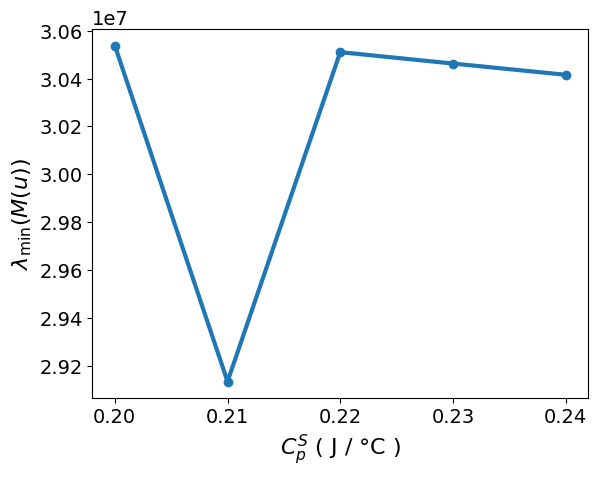

In [34]:
import matplotlib.pyplot as plt


plt.plot(CpS_values, e_opt, marker='o')
plt.xlabel('$C_p^S$ ( J / °C )')
plt.ylabel(r'$\lambda_{\min}(M(u))$')
plt.show()

The E-optimality objective, $\lambda_{\min}(\mathbf{M}(u) + M_0)$, remains on the order of $10^7$ over the tested local range of $C_p^S$. The smallest eigenvalue is largest near $C_p^S = 0.20$ and $0.22$ J/°C, decreases noticeably near $C_p^S = 0.21$ J/°C, and then changes only modestly from $C_p^S = 0.22$ to $0.24$ J/°C.

This shows that the amount of information in the weakest-informed direction is somewhat sensitive to the assumed value of $C_p^S$, but remains in the same order of magnitude across the tested range. Next, we check whether the optimized input profile and predicted temperature trajectory also change across this local range.

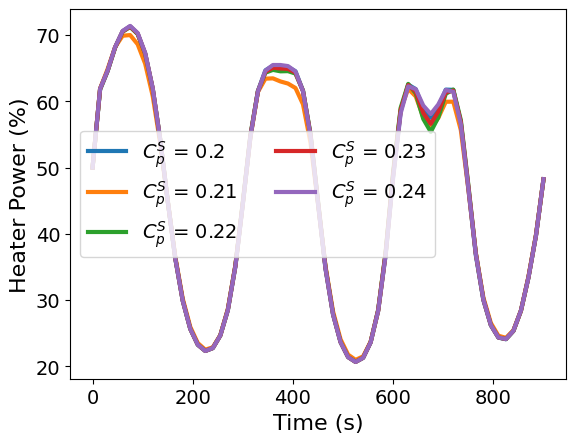

In [35]:
for i, v in enumerate(CpS_values):
    plt.plot(tc_data.time, u_solutions[i, :], label=f'$C_p^S$ = {v}')
plt.legend(ncol=2, loc='best')
plt.xlabel('Time (s)')
plt.ylabel('Heater Power (%)')
plt.show()

The corresponding optimal heater profiles are nearly identical across the tested values of $C_p^S$. All solutions retain the same repeated heating and cooling structure, with only small differences in the timing and magnitude of the heater input. Over this local range, changing $C_p^S$ has little effect on the E-optimal input design.

This suggests that the E-optimal design is locally robust to perturbations in the assumed sensor heat capacity.

Next, we examine the corresponding sensor-temperature profiles.

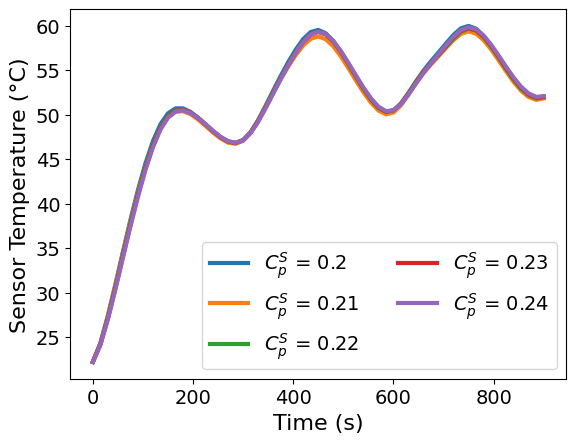

In [36]:
for i, v in enumerate(CpS_values):
    plt.plot(tc_data.time, Ts_solutions[i, :], label=f'$C_p^S$ = {v}')
plt.legend(ncol=2, loc='best')
plt.xlabel('Time (s)')
plt.ylabel('Sensor Temperature (°C)')
plt.show()

The predicted sensor-temperature trajectories are also very similar across the tested values of $C_p^S$. The profiles follow the same heating and cooling pattern, with only small differences in peak temperature and cooling behavior.

Together, the heater profiles and temperature trajectories suggest that the E-optimal design is locally robust to small changes in $C_p^S$ around the nominal value, even though the value of the E-optimality objective itself changes across the tested range.

The local sensitivity analysis shows that the E-optimal design structure is fairly stable near the nominal value of $C_p^S$. The heater profiles and predicted temperature trajectories remain qualitatively similar across the tested range, even though the value of the E-optimality objective changes.

This tells us that E-optimality is doing what it is designed to do: it focuses on the weakest-informed direction by increasing the smallest eigenvalue of the FIM. However, to understand the overall quality of the information matrix, we should look at the entire eigenvalue spectrum, not only the smallest eigenvalue.

For the E-optimal design, the smallest eigenvalue is approximately

$$
\lambda_{\min} \approx 3.05 \times 10^7,
$$

while the largest eigenvalue is approximately

$$
\lambda_{\max} \approx 1.31 \times 10^{11}.
$$

Therefore, the ratio between the largest and smallest eigenvalues is approximately

$$
\frac{\lambda_{\max}}{\lambda_{\min}}
\approx
\frac{1.31 \times 10^{11}}{3.05 \times 10^7}
\approx 4.3 \times 10^3.
$$

This ratio is a measure of conditioning. A smaller ratio means the FIM has a more balanced distribution of information across parameter directions. A very large ratio means that some parameter directions are much better informed than others.

Although E-optimality improves the weakest-informed direction, the FIM is still unevenly conditioned. This motivates modified E-optimality, which does not focus only on the smallest eigenvalue. Instead, it seeks to reduce the ratio between the largest and smallest eigenvalues, encouraging a more balanced information matrix.

## Modified E (ME)-optimality

We now turn to modified E-optimality, which uses the ratio between the largest and smallest eigenvalues of the updated FIM:

$$
\frac{\lambda_{\max}(\mathbf{M}(u) + \mathbf{M}_0)}
{\lambda_{\min}(\mathbf{M}(u) + \mathbf{M}_0)}.
$$

ME-optimality minimizes this ratio:

$$
\min_u
\frac{\lambda_{\max}(\mathbf{M}(u) + \mathbf{M}_0)}
{\lambda_{\min}(\mathbf{M}(u) + \mathbf{M}_0)}.
$$

A smaller ratio corresponds to a better-conditioned information matrix. Next, we solve the ME-optimal design problem.

In [37]:

# Create the design of experiments object
TC_Lab_DoE_ME = DesignOfExperiments(
    experiment=doe_experiment,
    step=1e-2,
    scale_constant_value=1,
    scale_nominal_param_value=False,
    objective_option="condition_number",  # ME-optimality
    prior_FIM=FIM,
    tee=True,
    solver = solver,
    jac_initial=init_jac,
    fim_initial=init_fim,
)

# Use the GreyBox objective implementation
TC_Lab_DoE_ME.use_grey_box = True

# Solve
TC_Lab_DoE_ME.run_doe()

Ipopt 3.14.19: max_iter=3000
tol=1e-05
linear_solver=ma57
nlp_scaling_method=gradient-based
acceptable_tol=0.001


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************

This is Ipopt version 3.14.19, running with linear solver ma57.

Number of nonzeros in equality constraint Jacobian...:      720
Number of nonzeros in inequality constraint Jacobian.:        0
Number of nonzeros in Lagrangian Hessian.............:        0

Total number of variables............................:      242
                     variables with only lower bounds:        0
                variables with lower and upper bounds:      120
                     variables with only upper bo

Let us visualize the experiment

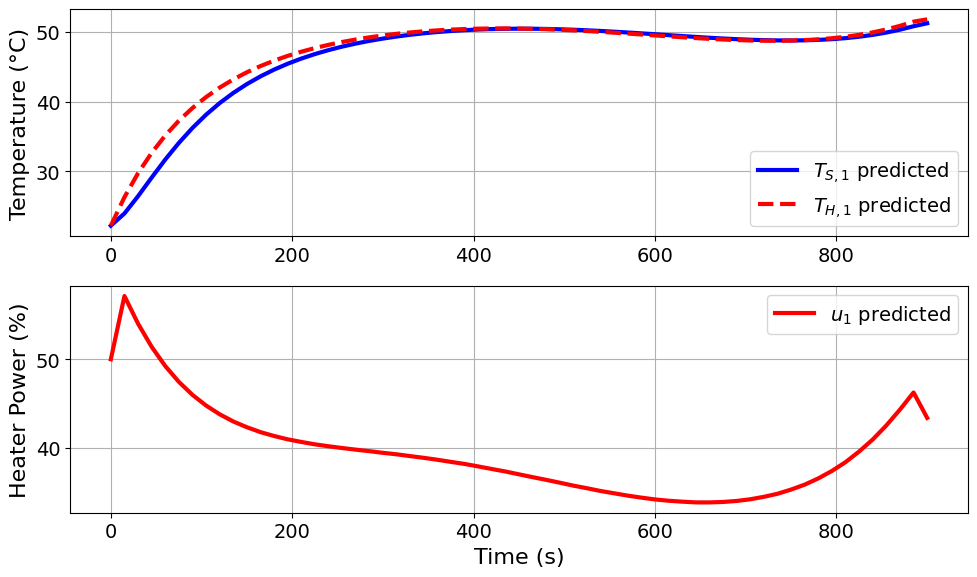

Model parameters:
Ua = 0.0421 Watts/°C
Ub = 0.012 Watts/°C
CpH = 5.9717 Joules/°C
CpS = 0.24 Joules/°C
 


In [38]:
MEopt_pyomo_doe_results = extract_plot_results(None, TC_Lab_DoE_ME.model.fd_scenario_blocks[0])

In [39]:
print("=== ME-optimal design summary ===")


results_summary(TC_Lab_DoE_ME.results["FIM"])

=== ME-optimal design summary ===
======Results Summary======
Five design criteria log10() value:
Pseudo A-optimality: 10.188854124106463
A-optimality: -8.235704565500443
D-optimality: 36.37219938953374
E-optimality: 8.618788862745863
Modified E-optimality: 1.5162661050581965

FIM:
 [[np.float64(13647525629.185654), np.float64(20460197.463154886), np.float64(-589939.141798404), np.float64(6092.60579389576)], [np.float64(20460197.463154886), np.float64(942799806.9558017), np.float64(28383785.15445074), np.float64(-613.0009844481316)], [np.float64(-589939.141798404), np.float64(28383785.15445074), np.float64(417237138.5295629), np.float64(13.150057791096055)], [np.float64(6092.60579389576), np.float64(-613.0009844481316), np.float64(13.150057791096055), np.float64(439792311.56278193)]]

eigenvalues:
 [1.36475586e+10 9.44295513e+08 4.15708460e+08 4.39792312e+08]

Eigenvector matrix:
          eigvec_1  eigvec_2  eigvec_3  eigvec_4
Ua        -1.0000   -0.0016   -0.0001      -0.0
Ub        

The ME-optimal design improves the conditioning of the FIM by reducing the spread between the largest and smallest eigenvalues. For this design, the smallest eigenvalue is approximately $4.16 \times 10^8$, while the largest eigenvalue is approximately $1.36 \times 10^{10}$. This gives a largest-to-smallest eigenvalue ratio of about $3.3 \times 10^1$.

Compared with the E-optimal design, modified E-optimality produces a much more balanced eigenvalue spectrum. The weakest-informed direction is still dominated by $\mathrm{inv}\_C_p^S$, so the least-informed parameter direction has not changed. However, the information available in that direction has increased, and the overall FIM is substantially better conditioned.

Thus, for this TC Lab example, ME-optimality gives a better-conditioned FIM while still improving the same weak parameter direction. Let us visualize the resulting optimal control trajectory.

We now return to D-optimality which is another option available within `Pyomo.DoE` by setting `objective_option="determinant"`. This criterion seeks an experiment that increases the determinant of the Fisher information matrix, which corresponds to reducing the overall parameter uncertainty volume.

Ipopt 3.14.19: max_iter=3000
tol=1e-05
linear_solver=ma57
nlp_scaling_method=gradient-based
acceptable_tol=0.001


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************

This is Ipopt version 3.14.19, running with linear solver ma57.

Number of nonzeros in equality constraint Jacobian...:      720
Number of nonzeros in inequality constraint Jacobian.:        0
Number of nonzeros in Lagrangian Hessian.............:        0

Total number of variables............................:      242
                     variables with only lower bounds:        0
                variables with lower and upper bounds:      120
                     variables with only upper bo

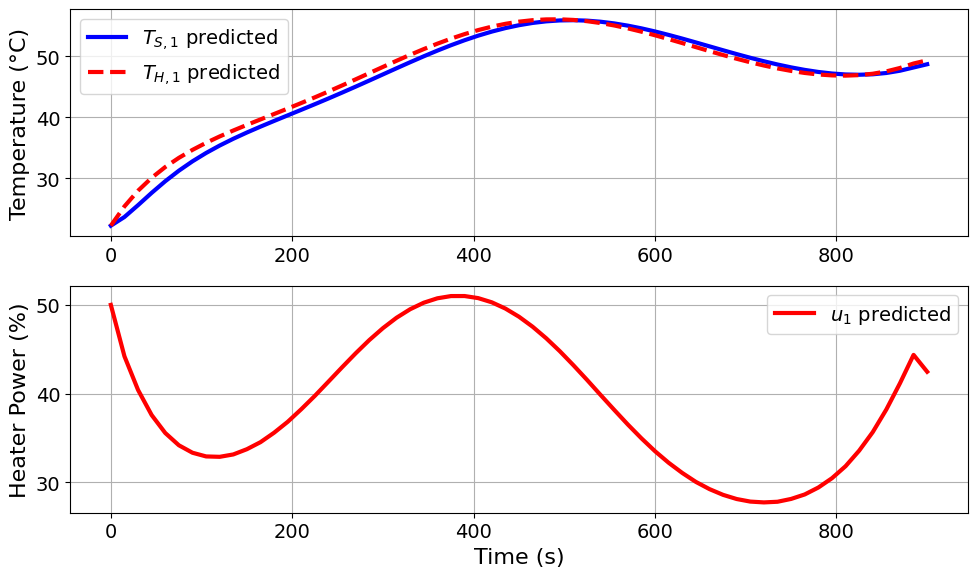

Model parameters:
Ua = 0.0421 Watts/°C
Ub = 0.012 Watts/°C
CpH = 5.9717 Joules/°C
CpS = 0.22 Joules/°C
 


In [40]:
# Create experiment object for design of experiments
doe_experiment = TC_Lab_experiment(data=tc_data, theta_initial=theta_values, number_of_states=number_tclab_states)

# Create the design of experiments object using our experiment instance from above
TC_Lab_DoE_D = DesignOfExperiments(experiment=doe_experiment, 
                                 step=1e-2,
                                 scale_constant_value=1,
                                 scale_nominal_param_value=False,
                                 objective_option="determinant",  # Now we specify a type of objective, D-opt = "determinant"
                                 prior_FIM=FIM,  # We use the prior information from the existing experiment!,,,,,,,,,,,,,,,,,,,,,,,
                                 tee=True,
                                 solver = solver,
                                 jac_initial=init_jac,
                                 fim_initial=init_fim,)

# Use the GreyBox objective implementation
TC_Lab_DoE_D.use_grey_box = True


TC_Lab_DoE_D.run_doe()

dopt_pyomo_doe_results = extract_plot_results(None, TC_Lab_DoE_D.model.fd_scenario_blocks[0])

The modified E-optimal input profile is noticeably different from the E-optimal design. Instead of using several shorter heating and cooling cycles, the ME-optimal design uses a smoother profile: it decreases the heater input early, increases it through the middle of the experiment, decreases it again, and then raises the heater input near the end.

This behavior is consistent with the objective: ME-optimality is not only trying to improve the weakest-informed direction, but also to improve the conditioning of the FIM. The resulting trajectory explores a broader heating and cooling response, which helps balance information across parameter directions.

Now that we have solved the A-, E-, ME-, and D-optimal design problems, we can compare the resulting Fisher information matrices using the same set of summary metrics. This comparison helps us see the tradeoffs between criteria: each design optimizes one objective, but may improve or degrade the others.

To compare the four optimized designs, we evaluate the same FIM summary metrics for each design. The table reports log-scaled values so the metrics can be compared on a similar numerical scale.

For the A-, D-, and E-style metrics, larger values indicate more information according to that criterion. For the condition-number metric, lower is better because it means the largest and smallest eigenvalues are closer together, corresponding to a better-conditioned FIM.

In [41]:
def fim_condition_metrics(FIM):
    eigvals = np.linalg.eigvalsh(np.array(FIM, dtype=float))
    lambda_min = np.min(eigvals)
    lambda_max = np.max(eigvals)
    condition_number = lambda_max / lambda_min

    return {
        "λ_min": lambda_min,
        "λ_max": lambda_max,
        "κ(M) = λ_max / λ_min": condition_number,
    }


condition_df = pd.DataFrame(
    {
        "D-opt design": fim_condition_metrics(TC_Lab_DoE_D.results["FIM"]),
        "A-opt design": fim_condition_metrics(TC_Lab_DoE_A.results["FIM"]),
        "E-opt design": fim_condition_metrics(TC_Lab_DoE_E.results["FIM"]),
        "ME-opt design": fim_condition_metrics(TC_Lab_DoE_ME.results["FIM"]),
    }
).T

condition_df = condition_df.round(
    {
        "λ_min": 2,
        "λ_max": 2,
        "κ(M) = λ_max / λ_min": 2,
    }
)

print("=== FIM conditioning comparison ===")
display(condition_df)

=== FIM conditioning comparison ===


,λ_min,λ_max,κ(M) = λ_max / λ_min
D-opt design,3.718573e+08,1.028103e+11,276.48
A-opt design,3.990047e+05,1.178945e+11,295471.56
E-opt design,3.051022e+07,1.305355e+11,4278.42
ME-opt design,4.157085e+08,1.364756e+10,32.83


The ME-optimal design gives the smallest condition number among the four designs. The condition number decreases from about $4.28 \times 10^3$ for the E-optimal design to about $3.28 \times 10^1$ for the ME-optimal design. This means the ME-optimal design produces a substantially better-conditioned FIM.

The improvement comes from producing a more balanced eigenvalue spectrum. For the ME-optimal design, $\lambda_{\min}$ is approximately $4.16 \times 10^8$, while $\lambda_{\max}$ is approximately $1.36 \times 10^{10}$. Compared with the E-optimal design, the smallest eigenvalue increases and the largest eigenvalue decreases, reducing the largest-to-smallest eigenvalue ratio.

Overall, this example shows that the choice of design criterion changes what aspect of the Fisher information matrix is emphasized. D-optimality improves the determinant-based measure of total information, A-optimality targets an average uncertainty measure, E-optimality directly improves the weakest-informed parameter direction, and modified E-optimality improves the conditioning of the FIM.

For the TC Lab example, all four designs produce informative experiments, but they differ in how they distribute information across parameter directions. The weakest-informed direction remains associated with $\mathrm{inv}\_C_p^S$, which reflects uncertainty in the sensor heat-capacity parameter. E-optimality increases information in this direction, while modified E-optimality gives the best-conditioned FIM by reducing the spread between the largest and smallest eigenvalues.

The main takeaway is that there is no single universally “best” optimality criterion. The appropriate choice depends on the experimental goal: use D- or A-optimality when the goal is to improve overall information content, use E-optimality when the goal is to improve the least-informed direction, and use modified E-optimality when the goal is to obtain a more balanced, better-conditioned information matrix.